# PCA (Rank-K Reconstruction) on Correlation Matrices
Apply rank-K eigen-decomposition and reconstruction on each correlation matrix independently.
Compute reconstruction errors (MSE, MAE, Frobenius) on the test set only, averaged across all matrices.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore', message='.*Clustering large matrix.*')

np.set_printoptions(suppress=True, precision=4)

## Step 1: Load Train/Val/Test Splits
Load correlation matrices from an existing dataset folder under `data/processed/dataset/`.
The folder must contain `train.pt`, `val.pt`, and `test.pt` with correlation matrices already split.

In [2]:
# Dataset path configuration
DATA_DIR = Path('../data/processed/dataset')
DATASET_NAME = 'data_00_20_w724_s10'
DATASET_DIR = DATA_DIR / DATASET_NAME

TRAIN_FILE = DATASET_DIR / 'train.pt'
VAL_FILE = DATASET_DIR / 'val.pt'
TEST_FILE = DATASET_DIR / 'test.pt'

for split_path in (TRAIN_FILE, VAL_FILE, TEST_FILE):
    if not split_path.exists():
        raise FileNotFoundError(f'File not found: {split_path.resolve()}')

print(f'Dataset folder: {DATASET_DIR.name}')
print(f'Train: {TRAIN_FILE.name} | Val: {VAL_FILE.name} | Test: {TEST_FILE.name}')

Dataset folder: data_00_20_w724_s10
Train: train.pt | Val: val.pt | Test: test.pt


In [3]:
def load_corr_payload(pt_path: Path):
    payload = torch.load(pt_path, map_location='cpu')

    if isinstance(payload, dict):
        corr_tensor = payload.get('corr_tensor', None)
        meta = {k: v for k, v in payload.items() if k != 'corr_tensor'}
    elif isinstance(payload, torch.Tensor):
        corr_tensor = payload
        meta = {}
    else:
        raise TypeError(f'Unsupported .pt format: {type(payload)}')

    if corr_tensor is None:
        raise KeyError('corr_tensor key not found in .pt file')

    if corr_tensor.ndim != 3 or corr_tensor.shape[1] != corr_tensor.shape[2]:
        raise ValueError(f'Invalid shape for corr_tensor: {corr_tensor.shape}')

    return corr_tensor.float(), meta


train_corr, train_meta = load_corr_payload(TRAIN_FILE)
val_corr, val_meta = load_corr_payload(VAL_FILE)
test_corr, test_meta = load_corr_payload(TEST_FILE)

if train_corr.shape[1:] != test_corr.shape[1:]:
    raise ValueError(f'Train/test asset dims mismatch: {train_corr.shape} vs {test_corr.shape}')
if val_corr.shape[1:] != train_corr.shape[1:]:
    raise ValueError(f'Val/train asset dims mismatch: {val_corr.shape} vs {train_corr.shape}')

print(f'train_corr shape: {tuple(train_corr.shape)}')
print(f'val_corr shape:   {tuple(val_corr.shape)}')
print(f'test_corr shape:  {tuple(test_corr.shape)}')

train_corr shape: (289, 362, 362)
val_corr shape:   (82, 362, 362)
test_corr shape:  (41, 362, 362)


## Step 2: Prepare Train/Val/Test Matrices
Use each correlation matrix directly as a 2D input (N x N).
The validation split is loaded for completeness but not used later.

In [4]:
train_np = train_corr.numpy()
val_np = val_corr.numpy()
test_np = test_corr.numpy()

n_train, n_assets, _ = train_np.shape
n_val = val_np.shape[0]
n_test = test_np.shape[0]

print(f'Train matrices: {n_train}')
print(f'Val matrices:   {n_val}')
print(f'Test matrices:  {n_test}')
print(f'Assets per matrix (N): {n_assets}')
print(f'Each input matrix shape: ({n_assets}, {n_assets})')

Train matrices: 289
Val matrices:   82
Test matrices:  41
Assets per matrix (N): 362
Each input matrix shape: (362, 362)


## Step 3: Rank-K Reconstruction on Test Set
For every matrix:
- Input shape: N x N
- Keep only the top-K eigenvalues/eigenvectors
- Reconstructed matrix (rank-K): N x N
Errors are computed on the test split.

In [6]:
def rank_k_reconstruct(corr_mats: np.ndarray, n_components: int):
    if corr_mats.ndim != 3 or corr_mats.shape[1] != corr_mats.shape[2]:
        raise ValueError(f'Expected shape (n_samples, N, N), got {corr_mats.shape}')

    n_samples, n_assets, _ = corr_mats.shape
    if not (1 <= n_components <= n_assets):
        raise ValueError(f'n_components must be in [1, {n_assets}]')

    recon_mats = np.empty_like(corr_mats, dtype=float)
    explained_variance = np.zeros((n_samples, n_components), dtype=float)

    for i in range(n_samples):
        mat = corr_mats[i]

        # Eigen-decomposition of the correlation matrix (symmetric).
        eigenvalues, eigenvectors = np.linalg.eigh(mat)
        idx = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[idx]
        eigenvectors = eigenvectors[:, idx]

        top_vals = eigenvalues[:n_components]
        top_vecs = eigenvectors[:, :n_components]

        # Rank-K reconstruction using the top eigenpairs.
        recon_mats[i] = (top_vecs * top_vals) @ top_vecs.T

        total_var = float(np.sum(eigenvalues))
        explained_variance[i, :] = 0.0 if total_var == 0.0 else (top_vals / total_var)

    return {
        'recon_corr': recon_mats,
        'explained_variance': explained_variance
    }

In [7]:
N_COMPONENTS = 12
if N_COMPONENTS > n_assets:
    raise ValueError(f'N_COMPONENTS={N_COMPONENTS} is too large, max is {n_assets}')

rankk_out = rank_k_reconstruct(test_np, n_components=N_COMPONENTS)
recon_corr = rankk_out['recon_corr']
mean_explained_ratio = rankk_out['explained_variance'].mean(axis=0)

var_percent = mean_explained_ratio.sum() * 100
print('--- Rank-K Reconstruction (test set) ---')
print(f'Test tensor shape:          {test_np.shape}')
print(f'Reconstructed test shape:   {recon_corr.shape}')
print(f'Components kept (K):        {N_COMPONENTS}')
print(f'Mean explained variance:    {var_percent:.2f}%\n')
for idx, var in enumerate(mean_explained_ratio):
    print(f'Mean variance PC{idx+1}: {(var * 100):.2f}%')

--- Rank-K Reconstruction (test set) ---
Test tensor shape:          (41, 362, 362)
Reconstructed test shape:   (41, 362, 362)
Components kept (K):        12
Mean explained variance:    55.39%

Mean variance PC1: 37.54%
Mean variance PC2: 5.30%
Mean variance PC3: 2.61%
Mean variance PC4: 1.89%
Mean variance PC5: 1.52%
Mean variance PC6: 1.27%
Mean variance PC7: 1.14%
Mean variance PC8: 0.99%
Mean variance PC9: 0.91%
Mean variance PC10: 0.81%
Mean variance PC11: 0.73%
Mean variance PC12: 0.66%


## Step 4: Reconstruct Correlation Matrices
Reconstruct each matrix from its top-K eigenpairs (rank-K). The result is symmetric by construction.

In [8]:
print(f'orig_corr shape: {test_np.shape}')
print(f'recon_corr shape: {recon_corr.shape}')

orig_corr shape: (41, 362, 362)
recon_corr shape: (41, 362, 362)


## Step 5: Matrix-Level Reconstruction Visualization
Visualize one reconstructed matrix with:
- Hierarchical clustering heatmaps (original, reconstructed, error)
- Standard heatmaps without clustering (original order preserved)

Original Matrix:
[[1.     0.3398 0.3781 0.309  0.5604]
 [0.3398 1.     0.2909 0.5142 0.4363]
 [0.3781 0.2909 1.     0.2982 0.3681]
 [0.309  0.5142 0.2982 1.     0.4061]
 [0.5604 0.4363 0.3681 0.4061 1.    ]]
Reconstructed Matrix:
[[0.5812 0.3198 0.3611 0.3118 0.5765]
 [0.3198 0.5647 0.3374 0.5205 0.4326]
 [0.3611 0.3374 0.4168 0.3592 0.4108]
 [0.3118 0.5205 0.3592 0.5989 0.3899]
 [0.5765 0.4326 0.4108 0.3899 0.656 ]]
Error Matrix:
[[-0.4188 -0.0199 -0.0171  0.0028  0.0161]
 [-0.0199 -0.4353  0.0465  0.0062 -0.0037]
 [-0.0171  0.0465 -0.5832  0.0609  0.0427]
 [ 0.0028  0.0062  0.0609 -0.4011 -0.0161]
 [ 0.0161 -0.0037  0.0427 -0.0161 -0.344 ]]
Sample index: 0
MSE: 0.000766 | MAE: 0.015376 | Frobenius: 10.020245
Error range - Min: -0.917411 | Max: 0.239062


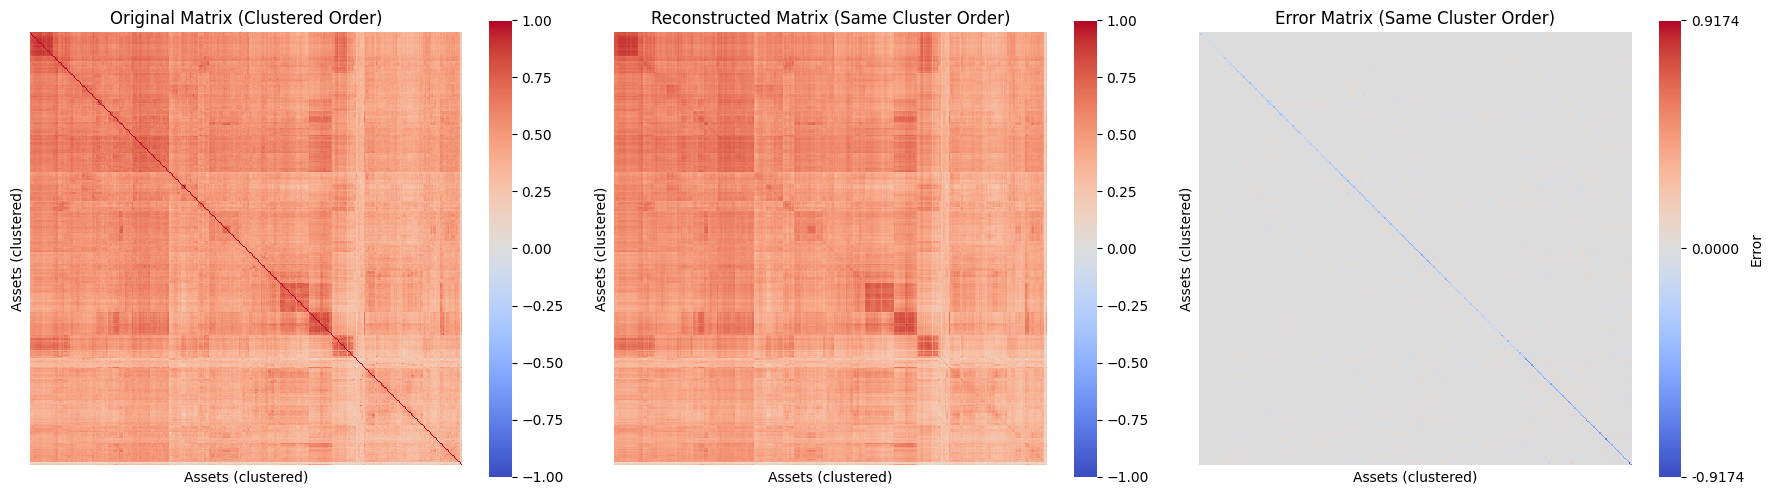

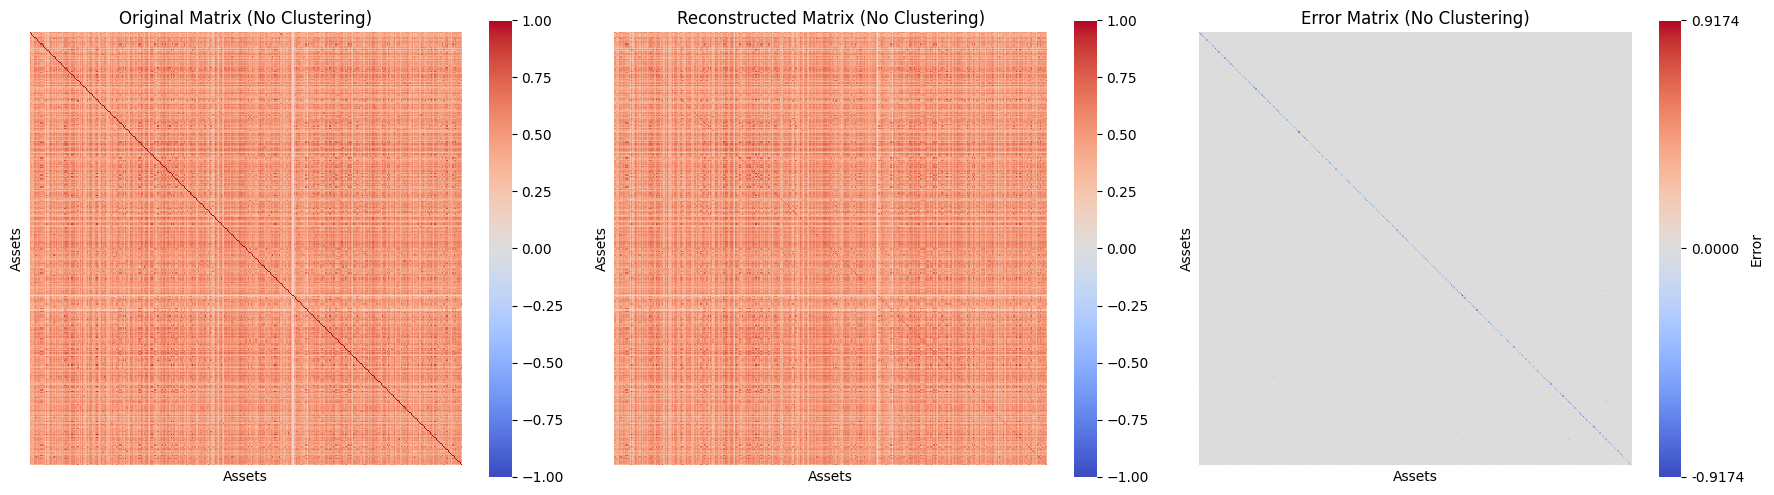

In [9]:
SAMPLE_IDX = 0

if not (0 <= SAMPLE_IDX < test_np.shape[0]):
    raise ValueError(f'SAMPLE_IDX must be in [0, {test_np.shape[0] - 1}]')

orig_mat = test_np[SAMPLE_IDX]
recon_mat = recon_corr[SAMPLE_IDX]
err_mat = recon_mat - orig_mat

print(f"Original Matrix:\n{orig_mat[:5, :5]}")  # Print the top-left 5x5 block of the original matrix for inspection
print(f"Reconstructed Matrix:\n{recon_mat[:5, :5]}")  # Print the top-left 5x5 block of the reconstructed matrix for inspection
print(f"Error Matrix:\n{err_mat[:5, :5]}")  # Print the top-left 5x5 block of the error matrix for inspection

mse_sample = float(np.mean((recon_mat - orig_mat) ** 2))
mae_sample = float(np.mean(np.abs(recon_mat - orig_mat)))
fro_sample = float(np.linalg.norm(recon_mat - orig_mat, ord='fro'))

print(f'Sample index: {SAMPLE_IDX}')
print(f'MSE: {mse_sample:.6f} | MAE: {mae_sample:.6f} | Frobenius: {fro_sample:.6f}')
print(f'Error range - Min: {err_mat.min():.6f} | Max: {err_mat.max():.6f}')

# Use the same colormap for all matrices.
shared_cmap = 'coolwarm'

# Error scale must be symmetric around zero: [-max|err|, +max|err|]
err_abs_max = float(np.max(np.abs(err_mat)))
if err_abs_max == 0:
    err_abs_max = 1e-6

# Build a single cluster ordering from the original matrix and reuse it for all three panels.
cluster_ref = sns.clustermap(
    orig_mat,
    vmin=-1,
    vmax=1,
    cmap=shared_cmap,
    linewidths=0,
    figsize=(8, 8),
    cbar_kws={'label': 'Correlation'},
)
row_order = cluster_ref.dendrogram_row.reordered_ind
col_order = cluster_ref.dendrogram_col.reordered_ind
plt.close(cluster_ref.fig)

orig_mat_clustered = orig_mat[np.ix_(row_order, col_order)]
recon_mat_clustered = recon_mat[np.ix_(row_order, col_order)]
err_mat_clustered = err_mat[np.ix_(row_order, col_order)]

# Clustered heatmaps in a single side-by-side figure (without dendrograms).
fig_cluster, axes_cluster = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(
    orig_mat_clustered,
    ax=axes_cluster[0],
    vmin=-1,
    vmax=1,
    cmap=shared_cmap,
    square=True,
 )
axes_cluster[0].set_title('Original Matrix (Clustered Order)')

sns.heatmap(
    recon_mat_clustered,
    ax=axes_cluster[1],
    vmin=-1,
    vmax=1,
    cmap=shared_cmap,
    square=True,
 )
axes_cluster[1].set_title('Reconstructed Matrix (Same Cluster Order)')

hm_cluster_err = sns.heatmap(
    err_mat_clustered,
    ax=axes_cluster[2],
    vmin=-err_abs_max,
    vmax=err_abs_max,
    cmap=shared_cmap,
    center=0,
    square=True,
    cbar_kws={'label': 'Error'},
)
axes_cluster[2].set_title('Error Matrix (Same Cluster Order)')

cbar_cluster = hm_cluster_err.collections[0].colorbar
cbar_cluster.set_ticks([-err_abs_max, 0, err_abs_max])
cbar_cluster.set_ticklabels([f'{-err_abs_max:.4f}', '0.0000', f'{err_abs_max:.4f}'])

for ax in axes_cluster:
    ax.set_xlabel('Assets (clustered)')
    ax.set_ylabel('Assets (clustered)')
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

# Standard heatmaps (no clustering, original matrix order)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(orig_mat, ax=axes[0], vmin=-1, vmax=1, cmap=shared_cmap, square=True)
axes[0].set_title('Original Matrix (No Clustering)')

sns.heatmap(recon_mat, ax=axes[1], vmin=-1, vmax=1, cmap=shared_cmap, square=True)
axes[1].set_title('Reconstructed Matrix (No Clustering)')

hm = sns.heatmap(err_mat, ax=axes[2], vmin=-err_abs_max, vmax=err_abs_max, cmap=shared_cmap, center=0, square=True, cbar_kws={'label': 'Error'})
axes[2].set_title('Error Matrix (No Clustering)')
# Set colorbar ticks for standard heatmap
cbar = hm.collections[0].colorbar
cbar.set_ticks([-err_abs_max, 0, err_abs_max])
cbar.set_ticklabels([f'{-err_abs_max:.4f}', '0.0000', f'{err_abs_max:.4f}'])

for ax in axes:
    ax.set_xlabel('Assets')
    ax.set_ylabel('Assets')
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## Step 6: Calculate Reconstruction Errors (Test Set)
Measure reconstruction quality on the test split using three metrics:
- **MSE**: Mean Squared Error
- **MAE**: Mean Absolute Error  
- **Frobenius**: Frobenius norm of the difference

In [11]:
def reconstruction_errors(original: np.ndarray, reconstructed: np.ndarray):
    diff = original - reconstructed

    mse_per_matrix = np.mean(diff ** 2, axis=(1, 2))
    mae_per_matrix = np.mean(np.abs(diff), axis=(1, 2))
    fro_per_matrix = np.linalg.norm(diff, ord='fro', axis=(1, 2))

    summary = pd.DataFrame({
        'MSE': mse_per_matrix,
        'MAE': mae_per_matrix,
        'Frobenius': fro_per_matrix
    })

    stats = summary.agg(['mean', 'std', 'min', 'median', 'max']).T
    return summary, stats


orig_corr = test_np
errors_df, errors_stats = reconstruction_errors(orig_corr, recon_corr)

print('Reconstruction error statistics (test set):')
display(errors_stats)

Reconstruction error statistics (test set):


,mean,std,min,median,max
MSE,0.001128,0.000293,0.000728,0.001149,0.001717
MAE,0.017682,0.002145,0.014366,0.017729,0.021419
Frobenius,12.054793,1.591221,9.765436,12.270057,14.999221


## Step 7: Error Analysis Across Components
Sweep over different numbers of K components (1 to n_assets) and track how reconstruction errors change on the test set.

In [13]:
# Error evaluation varying number of components (reconstruction on test set)
candidate_components = [1, 2, 3, 5, 10, 12, 20, 30, 40, 50, 100, 200, 362]
candidate_components = [c for c in candidate_components if c <= n_assets]
print(f'Evaluating reconstruction errors for components: {candidate_components}')

rows = []
for n_comp in candidate_components:
    recon_out = rank_k_reconstruct(test_np, n_comp)
    recon = recon_out['recon_corr']
    _, stats = reconstruction_errors(test_np, recon)
    mean_explained_ratio = recon_out['explained_variance'].mean(axis=0)

    rows.append({
        'n_components': n_comp,
        'mean_explained_variance': float(mean_explained_ratio.sum()),
        'MSE_mean': float(stats.loc['MSE', 'mean']),
        'MAE_mean': float(stats.loc['MAE', 'mean']),
        'Frobenius_mean': float(stats.loc['Frobenius', 'mean'])
    })

sweep_df = pd.DataFrame(rows)
display(sweep_df)

Evaluating reconstruction errors for components: [1, 2, 3, 5, 10, 12, 20, 30, 40, 50, 100, 200, 362]


,n_components,mean_explained_variance,MSE_mean,MAE_mean,Frobenius_mean
0,1,0.375410,6.292144e-03,4.710137e-02,27.960027
1,2,0.428454,3.108684e-03,3.384655e-02,19.984841
2,3,0.454599,2.389769e-03,2.887836e-02,17.531011
3,5,0.488714,1.785333e-03,2.408424e-02,15.155880
4,10,0.539971,1.226861e-03,1.859899e-02,12.575634
5,12,0.553868,1.127776e-03,1.768223e-02,12.054793
6,20,0.597312,8.863443e-04,1.561010e-02,10.675263
7,30,0.640024,7.008145e-04,1.400678e-02,9.481421
8,40,0.676023,5.691268e-04,1.277976e-02,8.535588
9,50,0.707645,4.673452e-04,1.173424e-02,7.727615


## Step 8: Visualize Results
Generate plots showing:
1. **Mean cumulative explained variance** on the test set (top K)
2. **Reconstruction errors** (MSE, MAE, Frobenius) computed on the test set

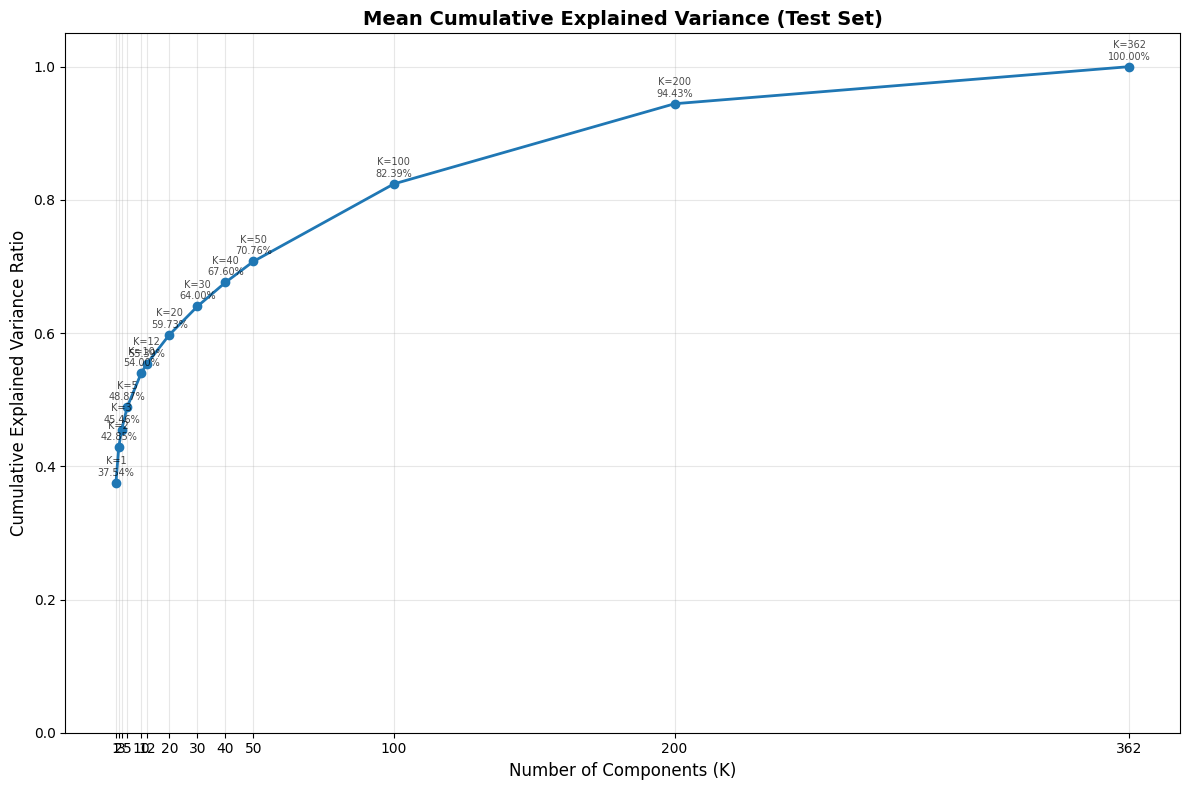

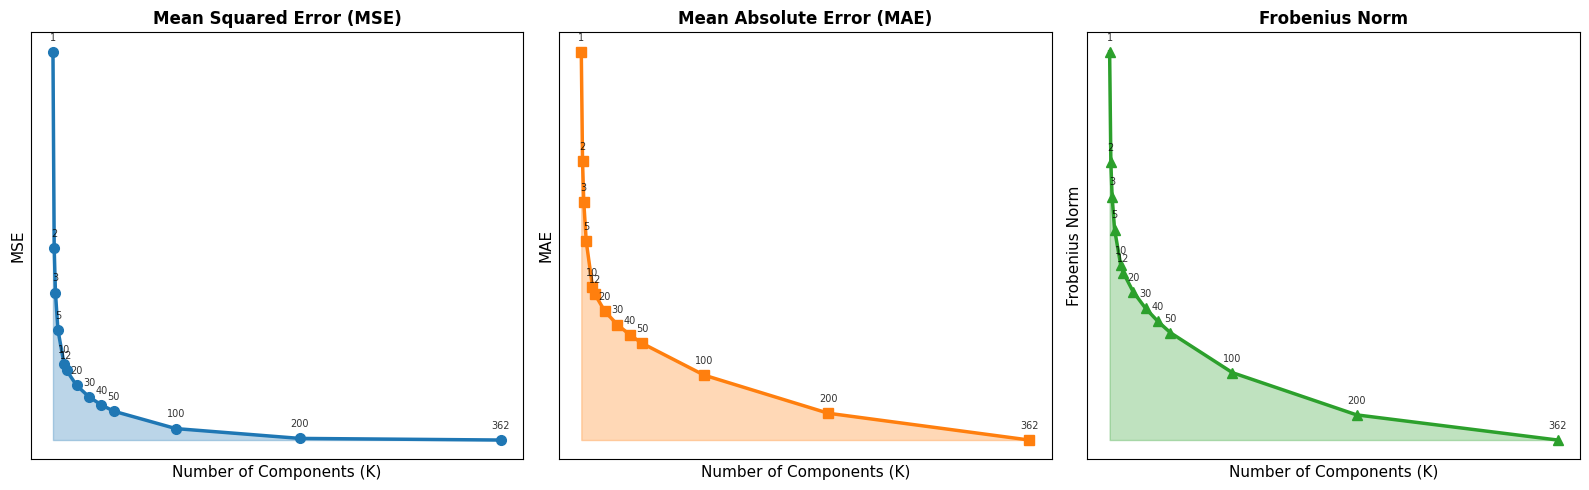

In [ ]:
# Plot 1: Mean Cumulative Explained Variance (test set)
fig1, ax1 = plt.subplots(figsize=(12, 8))

k_values = sweep_df['n_components'].to_numpy()
mean_cum_var = sweep_df['mean_explained_variance'].to_numpy()
ax1.plot(k_values, mean_cum_var, marker='o', linewidth=2, markersize=6)

# Add annotations with cumulative variance values at each marker
for k, val in zip(k_values, mean_cum_var):
    ax1.annotate(f'K={int(k)}\n{val*100:.2f}%',
                 xy=(k, val),
                 xytext=(0, 5),
                 textcoords='offset points',
                 ha='center',
                 fontsize=7,
                 alpha=0.7)

ax1.set_title('Mean Cumulative Explained Variance (Test Set)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Number of Components (K)', fontsize=12)
ax1.set_ylabel('Cumulative Explained Variance Ratio', fontsize=12)
ax1.set_xticks(k_values)
ax1.set_ylim(0, 1)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 2: Reconstruction Errors on Test Set with separate subplots for each metric
fig2, axes = plt.subplots(1, 3, figsize=(16, 5))

# MSE subplot
axes[0].plot(sweep_df['n_components'], sweep_df['MSE_mean'], marker='o', linewidth=2.5, markersize=7, color='#1f77b4')
axes[0].fill_between(sweep_df['n_components'], sweep_df['MSE_mean'], alpha=0.3, color='#1f77b4')
for i, (n_comp, val) in enumerate(zip(sweep_df['n_components'], sweep_df['MSE_mean'])):
    axes[0].annotate(f'{int(n_comp)}', xy=(n_comp, val), xytext=(0, 8), textcoords='offset points',
                     ha='center', fontsize=7, alpha=0.8)
axes[0].set_title('Mean Squared Error (MSE)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Components (K)', fontsize=11)
axes[0].set_ylabel('MSE', fontsize=11)
axes[0].grid(True, alpha=0.3)

# MAE subplot
axes[1].plot(sweep_df['n_components'], sweep_df['MAE_mean'], marker='s', linewidth=2.5, markersize=7, color='#ff7f0e')
axes[1].fill_between(sweep_df['n_components'], sweep_df['MAE_mean'], alpha=0.3, color='#ff7f0e')
for i, (n_comp, val) in enumerate(zip(sweep_df['n_components'], sweep_df['MAE_mean'])):
    axes[1].annotate(f'{int(n_comp)}', xy=(n_comp, val), xytext=(0, 8), textcoords='offset points',
                     ha='center', fontsize=7, alpha=0.8)
axes[1].set_title('Mean Absolute Error (MAE)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Components (K)', fontsize=11)
axes[1].set_ylabel('MAE', fontsize=11)
axes[1].grid(True, alpha=0.3)

# Frobenius norm subplot
axes[2].plot(sweep_df['n_components'], sweep_df['Frobenius_mean'], marker='^', linewidth=2.5, markersize=7, color='#2ca02c')
axes[2].fill_between(sweep_df['n_components'], sweep_df['Frobenius_mean'], alpha=0.3, color='#2ca02c')
for i, (n_comp, val) in enumerate(zip(sweep_df['n_components'], sweep_df['Frobenius_mean'])):
    axes[2].annotate(f'{int(n_comp)}', xy=(n_comp, val), xytext=(0, 8), textcoords='offset points',
                     ha='center', fontsize=7, alpha=0.8)
axes[2].set_title('Frobenius Norm', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Number of Components (K)', fontsize=11)
axes[2].set_ylabel('Frobenius Norm', fontsize=11)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()